In [17]:
import open3d as o3d
import cv2
import numpy as np
from ultralytics import YOLO
from scipy.spatial.transform import Rotation as R
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

image_path = "output_image_3.png"
ply_path = "output_pointcloud_3.ply"


model_path = "yolo12n.pt"
model = YOLO(model_path)

def read_image_and_pointcloud(image_path: str, ply_path: str):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    pcd = o3d.io.read_point_cloud(ply_path)
    points = np.asarray(pcd.points)
    return image, points

img, cloud = read_image_and_pointcloud(image_path, ply_path)

# Camera intrinsic matrix K
K = np.array([
    [336.0996183406607, 0.0, 480.0],
    [0.0, 336.0996183406607, 300.0],
    [0.0, 0.0, 1.0]
])

# Extrinsics: from LiDAR to camera (rotation + translation)
quat = [0.7071, 0.0, 0.0, 0.7071]  # quaternion (x, y, z, w)
R_lidar_to_cam = R.from_quat(quat).as_matrix()
t_lidar_to_cam = np.array([-0.297, -0.296, -0.425]).reshape((3, 1))


def project_lidar_to_image(lidar_points, K, R, t):
    # Transform points from LiDAR frame to camera frame
    points_cam = (R @ lidar_points.T + t).T
    # Filter out points behind the camera
    in_front = points_cam[:, 2] > 0
    points_cam = points_cam[in_front]
    # Project to image plane
    proj = (K @ points_cam.T).T
    pixels = proj[:, :2] / proj[:, 2:3]
    return pixels, points_cam

def draw_projected_points_on_image(image, pixels, bboxes=None, color=(0, 255, 0)):
    img_copy = image.copy()
    
    # Draw projected points
    for pt in pixels.astype(int):
        x, y = pt
        if 0 <= x < img_copy.shape[1] and 0 <= y < img_copy.shape[0]:
            cv2.circle(img_copy, (x, y), 1, color, -1)
    
    # # Draw and label bounding boxes
    # if bboxes:
    #     for i, (x1, y1, x2, y2) in enumerate(bboxes):
    #         cv2.rectangle(img_copy, (x1, y1), (x2, y2), (255, 165, 0), 2)
    #         label = f"DETECTION #{i}"
    #         # cv2.putText(img_copy, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
    #         #             0.6, (255, 165, 0), 2, lineType=cv2.LINE_AA)
    
    return img_copy


def extract_points_in_bbox(pixels, cam_points, bbox):
    x1, y1, x2, y2 = bbox
    in_bbox = (
        (pixels[:, 0] >= x1) & (pixels[:, 0] <= x2) &
        (pixels[:, 1] >= y1) & (pixels[:, 1] <= y2)
    )
    return cam_points[in_bbox]

def plot_depth_histogram(points_3d, bbox_index, num_bins=60):
    depths = points_3d[:, 2]
    hist, bin_edges = np.histogram(depths, bins=num_bins)

    plt.figure(figsize=(8, 4))
    plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge', color='lightgreen', edgecolor='black')
    plt.title(f"Depth Histogram for Detection #{bbox_index}")
    plt.xlabel("Depth (Z in camera frame)")
    plt.xlim(0, 170)  # Limit x-axis to 100m
    plt.ylabel("Number of Points")
    plt.ylim(0, 200)
    plt.grid(True)
    plt.show()

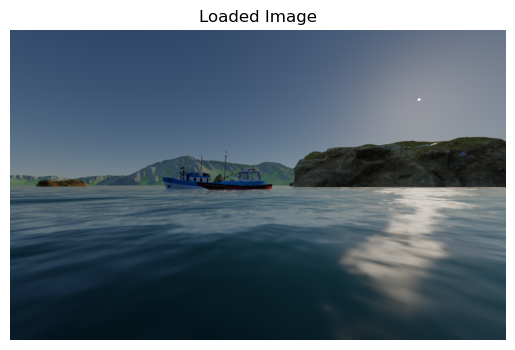

Loaded point cloud shape: (1806, 3)


In [14]:


# Show the image
plt.imshow(img)
plt.title("Loaded Image")
plt.axis("off")
plt.show()

print("Loaded point cloud shape:", cloud.shape)


0: 416x640 2 boats, 26.6ms
Speed: 5.5ms preprocess, 26.6ms inference, 9.8ms postprocess per image at shape (1, 3, 416, 640)


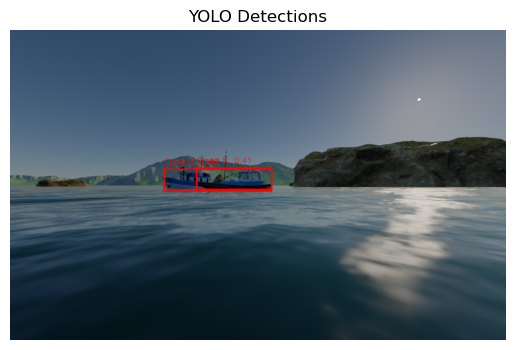

In [15]:
# Run detection
results = model(img)[0]  # We take the first image result

# Extract bounding boxes
detections = []
for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
    conf = float(box.conf[0])
    cls = int(box.cls[0])
    detections.append({
        "bbox": (x1, y1, x2, y2),
        "confidence": conf,
        "class": cls
    })

# Draw detections for verification
image_copy = img.copy()
for det in detections:
    x1, y1, x2, y2 = det["bbox"]
    cv2.rectangle(image_copy, (x1, y1), (x2, y2), (255, 0, 0), 2)
    cv2.putText(image_copy, f"Class {det['class']}, {det['confidence']:.2f}",
                (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)

plt.imshow(image_copy)
plt.title("YOLO Detections")
plt.axis("off")
plt.show()

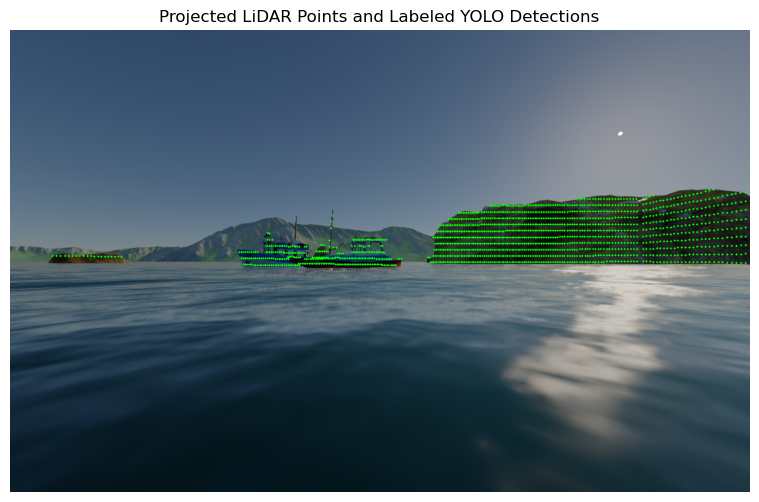

In [18]:
# Use projected LiDAR on image
pixels, cam_points = project_lidar_to_image(cloud, K, R_lidar_to_cam, t_lidar_to_cam)

# Extract bounding boxes
bboxes = [d["bbox"] for d in detections] if "detections" in locals() else [(250, 200, 390, 320)]

# Draw image with projected LiDAR points and labeled bounding boxes
overlay = draw_projected_points_on_image(img, pixels, bboxes)

# Show result
plt.figure(figsize=(10, 6))
plt.imshow(overlay)
plt.title("Projected LiDAR Points and Labeled YOLO Detections")
plt.axis("off")
plt.show()

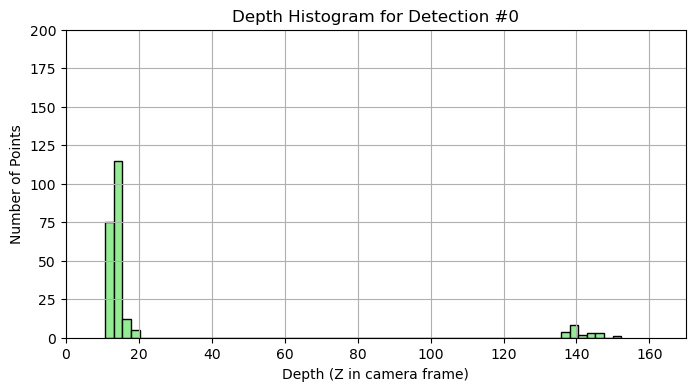

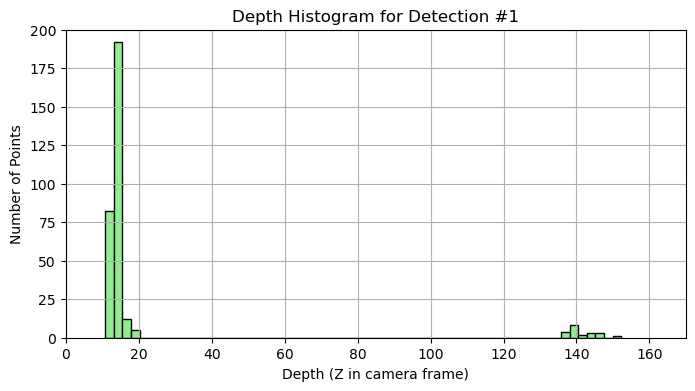

In [19]:


detections_frustum_points = []

# --- Loop through all detections ---
if bboxes:
    for idx, bbox in enumerate(bboxes):
        points_in_frustum = extract_points_in_bbox(pixels, cam_points, bbox)
        detections_frustum_points.append(points_in_frustum)
        if len(points_in_frustum) > 0:
            plot_depth_histogram(points_in_frustum, idx)
        else:
            print(f"No LiDAR points found in frustum of detection #{idx}")
else:
    print("No bounding boxes found.")

Detection #0: CoG at Z=13.73 (peak bin index = 1)


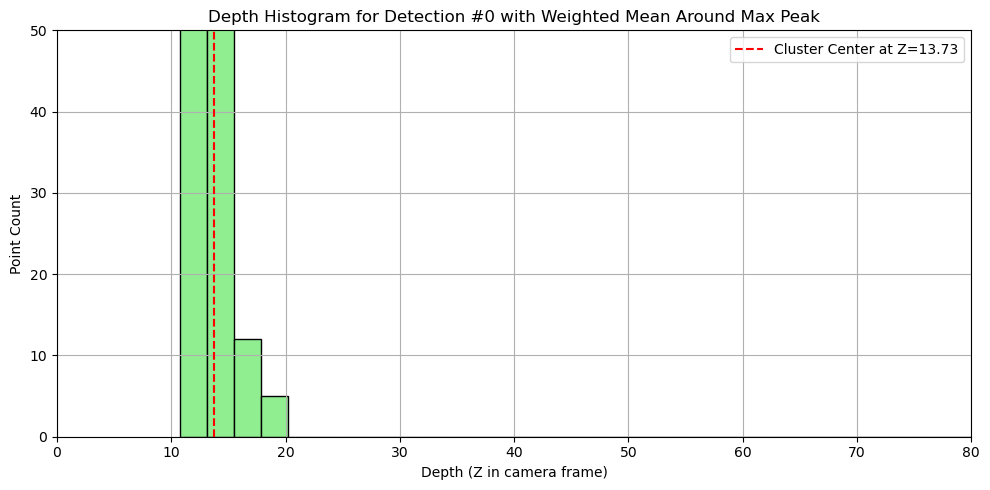

Detection #1: CoG at Z=13.85 (peak bin index = 1)


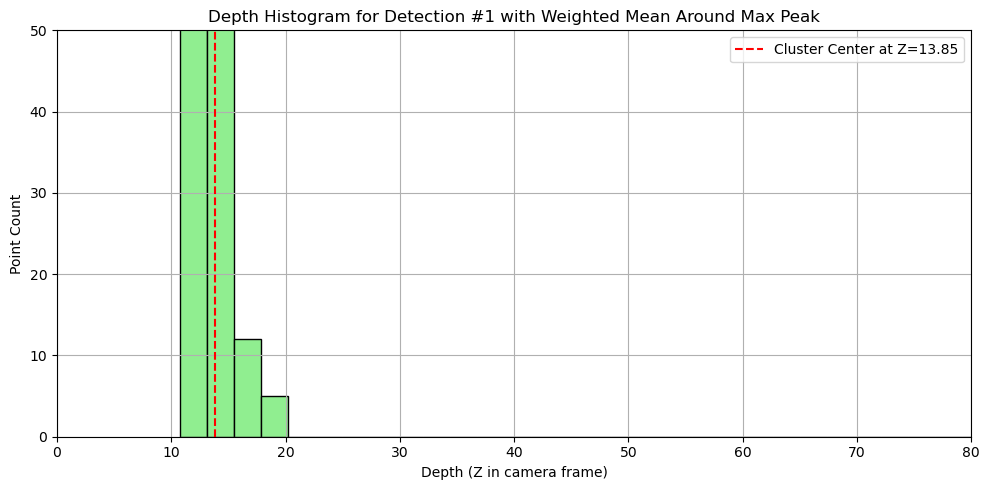

In [20]:

def estimate_cog_from_max_peak(hist, bin_edges, sigma=5):
    """
    Find the bin with the highest count, then compute a weighted center (CoG)
    of the neighborhood [i-σ, ..., i+σ].

    Returns:
        (peak_bin_idx, cog_z)
    """
    peak_idx = np.argmax(hist)

    # Define the neighborhood window
    start = max(peak_idx - sigma, 0)
    end = min(peak_idx + sigma + 1, len(hist))

    weights = hist[start:end]
    centers = [(bin_edges[i] + bin_edges[i + 1]) / 2 for i in range(start, end)]

    # Compute weighted average (center of gravity)
    cog_z = np.average(centers, weights=weights)

    return peak_idx, cog_z

# --- Loop through all detections ---
for idx, points_in_frustum in enumerate(detections_frustum_points):
    if len(points_in_frustum) > 0:
        depths = points_in_frustum[:, 2]
        hist, bin_edges = np.histogram(depths, bins=60)

        peak_idx, cog_z = estimate_cog_from_max_peak(hist, bin_edges, sigma=10)
        print(f"Detection #{idx}: CoG at Z={cog_z:.2f} (peak bin index = {peak_idx})")

        # --- Visualization ---
        plt.figure(figsize=(10, 5))
        plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), align='edge',
                color='lightgreen', edgecolor='black')
        plt.axvline(cog_z, color='red', linestyle='--', label=f"Cluster Center at Z={cog_z:.2f}")
        plt.title(f"Depth Histogram for Detection #{idx} with Weighted Mean Around Max Peak")
        plt.xlabel("Depth (Z in camera frame)")
        plt.xlim(0, 80)
        plt.ylabel("Point Count")
        plt.ylim(0, 50)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [21]:
def find_depth_range_around_peak(hist, bin_edges, peak_idx, gap_threshold=0):
    left = peak_idx
    right = peak_idx

    while left > 0 and hist[left - 1] > gap_threshold:
        left -= 1
    while right < len(hist) - 1 and hist[right + 1] > gap_threshold:
        right += 1

    z_min = bin_edges[left]
    z_max = bin_edges[right + 1]
    return z_min, z_max

def estimate_axis_line(points_in_frustum, z_min, z_max):
    filtered = points_in_frustum[(points_in_frustum[:, 2] >= z_min) & (points_in_frustum[:, 2] <= z_max)]
    if len(filtered) < 2:
        return None, None, filtered
    sorted_pts = filtered[np.argsort(filtered[:, 0])]
    left = sorted_pts[0]
    right = sorted_pts[-1]
    return left, right, filtered

def compute_rectangle_xy_on_ground(left_pt, right_pt, width):
    center = 0.5 * (left_pt + right_pt)
    center[2] = 0
    axis = right_pt[:2] - left_pt[:2]
    axis_length = np.linalg.norm(axis)
    if axis_length == 0:
        return None
    axis /= axis_length
    normal = np.array([-axis[1], axis[0]])
    half_len = 0.5 * axis_length
    half_wid = 0.5 * width
    p1 = center[:2] - half_len * axis - half_wid * normal
    p2 = center[:2] + half_len * axis - half_wid * normal
    p3 = center[:2] + half_len * axis + half_wid * normal
    p4 = center[:2] - half_len * axis + half_wid * normal
    corners = np.array([p1, p2, p3, p4])
    corners_3d = np.hstack((corners, np.zeros((4, 1))))
    return corners_3d

def visualize_in_o3d(full_cloud, filtered_points, left_pt, right_pt, rectangle_corners=None):
    pcd_full = o3d.geometry.PointCloud()
    pcd_full.points = o3d.utility.Vector3dVector(full_cloud)
    pcd_full.paint_uniform_color([0.8, 0.8, 0.8])
    pcd_filtered = o3d.geometry.PointCloud()
    pcd_filtered.points = o3d.utility.Vector3dVector(filtered_points)
    pcd_filtered.paint_uniform_color([0.1, 0.5, 1.0])
    line_pts = [left_pt, right_pt]
    lines = [[0, 1]]
    line_set = o3d.geometry.LineSet(
        points=o3d.utility.Vector3dVector(line_pts),
        lines=o3d.utility.Vector2iVector(lines)
    )
    line_set.colors = o3d.utility.Vector3dVector([[1, 0, 0]])
    geometries = [pcd_full, pcd_filtered, line_set]
    if rectangle_corners is not None:
        rectangle_lines = [[0, 1], [1, 2], [2, 3], [3, 0]]
        rect_set = o3d.geometry.LineSet(
            points=o3d.utility.Vector3dVector(rectangle_corners),
            lines=o3d.utility.Vector2iVector(rectangle_lines)
        )
        rect_set.colors = o3d.utility.Vector3dVector([[0, 1, 0] for _ in rectangle_lines])
        geometries.append(rect_set)
    o3d.visualization.draw_geometries(geometries)

In [22]:
for idx, points_in_frustum in enumerate(detections_frustum_points):
    if len(points_in_frustum) > 0:
        depths = points_in_frustum[:, 2]
        hist, bin_edges = np.histogram(depths, bins=60)

        peak_idx = np.argmax(hist)
        z_min, z_max = find_depth_range_around_peak(hist, bin_edges, peak_idx)
        left_pt, right_pt, filtered_points = estimate_axis_line(points_in_frustum, z_min, z_max)

        if left_pt is not None and right_pt is not None:
            axis_length = np.linalg.norm(right_pt[:2] - left_pt[:2])
            width = axis_length / 3.5  # Example ratio; adjust as needed
            rectangle = compute_rectangle_xy_on_ground(left_pt, right_pt, width)

            print(f"Detection #{idx}: Depth Range = ({z_min:.2f}, {z_max:.2f})")
            visualize_in_o3d(cloud, filtered_points, left_pt, right_pt, rectangle)
        else:
            print(f"Detection #{idx}: Not enough points to estimate axis or box.")

Detection #0: Depth Range = (10.80, 20.23)
Detection #1: Depth Range = (10.80, 20.23)
